In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [3]:
%load_ext autoreload
%autoreload 2

In [2]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

# load test samples
samples_idxs = np.arange(0, 1000)
test_samples_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = torch.from_numpy(np.load(test_samples_path)[samples_idxs]).to(device).to(torch.float32)

# load training samples (needed for the alpha normalization procedure)
train_samples_idxs = np.arange(0, 1000)
train_samples_path = Path("../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in train_samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(
    np.array(train_samples_normalization, dtype=np.float32)
).to(device)

missing keys: 0
unexpected keys: 0


In [11]:
A_sparse = np.load("forward_model/forward_model_sxr_full_geometry.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T
print(0.01*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.05*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.1*np.mean((y_tomo_clean.flatten()).cpu().numpy()))

0.04889717 0.24448586 0.4889717


In [12]:
A_sparse = np.load("forward_model/dmpx_geometry_matrix.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T
print(0.01*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.05*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.1*np.mean((y_tomo_clean.flatten()).cpu().numpy()))

0.10840717 0.5420359 1.0840718


In [13]:
A_sparse = np.load("forward_model/pilatus_geometry_matrix.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T
print(0.01*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.05*np.mean((y_tomo_clean.flatten()).cpu().numpy()), 0.1*np.mean((y_tomo_clean.flatten()).cpu().numpy()))

0.06925799 0.34628996 0.6925799


In [5]:
A_sparse = np.load("forward_model/forward_model_sxr_full_geometry.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)

In [7]:
test_samples.shape

torch.Size([1000, 120, 40])

In [8]:
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T

In [9]:
y_tomo_clean.shape

torch.Size([1000, 100])

In [10]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
noise_realizations = torch.randn_like(y_tomo_clean).cpu().numpy()
scaling_params = 1 + 999 * np.random.rand(test_samples.shape[0])
np.save("noise_realizations.npy", noise_realizations)
np.save("scaling_params.npy", scaling_params)

In [4]:
# for DMPX

A_sparse = np.load("forward_model/dmpx_geometry_matrix.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
noise_realizations = torch.randn_like(y_tomo_clean).cpu().numpy()
scaling_params = 1 + 999 * np.random.rand(test_samples.shape[0])
np.save("noise_realizations_dmpx.npy", noise_realizations)
np.save("scaling_params_dmpx.npy", scaling_params)

In [3]:
# for Pilatus

A_sparse = np.load("forward_model/pilatus_geometry_matrix.npy").astype(np.float32)
A_sparse /= A_sparse.max()
A_tomo = torch.from_numpy(A_sparse).to(device)
y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
noise_realizations = torch.randn_like(y_tomo_clean).cpu().numpy()
scaling_params = 1 + 999 * np.random.rand(test_samples.shape[0])
np.save("noise_realizations_pilatus.npy", noise_realizations)
np.save("scaling_params_pilatus.npy", scaling_params)

In [4]:
noise_realizations.shape

(1000, 80)

In [7]:
noise_realizations.shape

(1000, 256)

In [6]:
scaling_params.shape

(1000,)

In [11]:
noise_realizations.shape

(1000, 100)

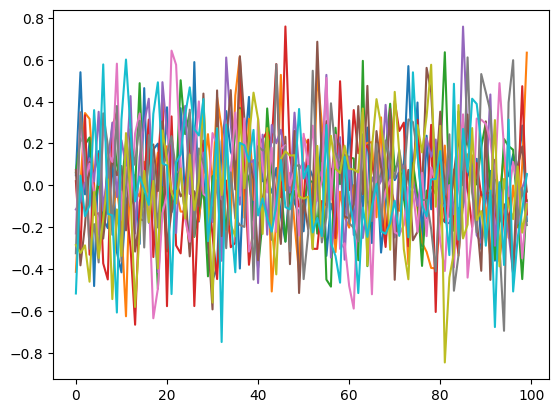

In [14]:
plt.plot(0.25*noise_realizations[:10,:].T)

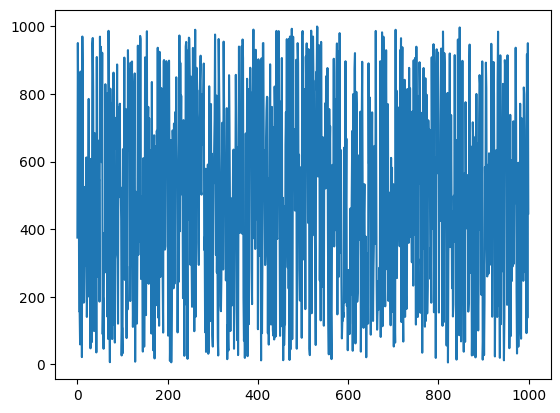

In [15]:
plt.plot(scaling_params)

In [ ]:
import copy

import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# configuration grid
noise_levels = [0.05, 0.1, 0.25, 0.5]
operators = {
    "sxr": Path("forward_model/forward_model_sxr_full_geometry.npy"),
    "dmpx": Path("forward_model/dmpx_geometry_matrix.npy"),
}
procedures = [False, True]  # False: raw; True: normalization + noise estimation

num_eval_samples = 3         # number of test samples to evaluate per setting
num_posterior_samples = 100
num_inference_steps = 250
zeta = 0.6
lambda_ = 300
scaling_params = 1+ 999*np.random.rand(test_samples.shape[0])

csv_dir = Path("metrics_csv")
csv_dir.mkdir(exist_ok=True)

for op_name, A_path in operators.items():
    # load and normalize operator
    A_sparse = np.load(A_path).astype(np.float32)
    A_sparse /= A_sparse.max()
    A_tomo = torch.from_numpy(A_sparse).to(device)
    print(f"\n=== operator {op_name}: A shape {tuple(A_tomo.shape)} ===")

    # clean synthetic measurements for this operator
    y_tomo_clean = test_samples.reshape(-1, H * W) @ A_tomo.T

    # training-sample projections for alpha normalization
    y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T

    for sigma_y_tomo in noise_levels:
        # seed so noise realisation is identical across procedure True/False
        SEED = 42
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        y_tomo_noisy_all = y_tomo_clean + sigma_y_tomo * torch.randn_like(y_tomo_clean)

        for procedure in procedures:
            print(f"-- sigma={sigma_y_tomo}, procedure={procedure}")

            rows = []
            for i in range(num_eval_samples):
                y_i = copy.deepcopy(y_tomo_noisy_all[i])
                x_gt_i = copy.deepcopy(test_samples[i])

                if procedure:
                    y_i *= scaling_params[i]
                    x_gt_i *= scaling_params[i]
                    sigma_est = estimate_noise_std(y_i.detach().cpu().numpy().reshape(1, -1))
                    sigma_est = float(sigma_est) if not hasattr(sigma_est, "item") else sigma_est.item()
                    alpha, _ = compute_normalization_coefficient(
                        y_i.reshape(1, -1), y_tomo_train, normalization_for_comparison="norm"
                    )
                    y_used = y_i / alpha
                    sigma_used = sigma_est / alpha
                    print(f" scaling={scaling_params[i]:.4f}, alpha={alpha:.4f}, sigma_true={sigma_y_tomo:.4f}, sigma_used={sigma_used:.4f}")
                else:
                    alpha = 1.0
                    sigma_used = sigma_y_tomo
                    y_used = y_i

                posterior_tomo, _, _ = sample_posterior_diffpir(
                    model=model,
                    schedule=schedule,
                    A=A_tomo,
                    y=y_used,
                    image_shape=(1, H, W),
                    num_samples=num_posterior_samples,
                    num_inference_steps=num_inference_steps,
                    zeta=zeta,
                    sigma_y=sigma_used,
                    lambda_=lambda_,
                )

                post_mean = posterior_tomo.mean(dim=0).squeeze() * alpha
                post_std = posterior_tomo.std(dim=0).squeeze() * alpha

                gt_np = x_gt_i.cpu().numpy()
                mean_np = post_mean.detach().cpu().numpy()
                data_range = float(gt_np.max() - gt_np.min())

                psnr_value = psnr(gt_np, mean_np, data_range=data_range)
                ssim_value = ssim(gt_np, mean_np, data_range=data_range)
                mse_value = float(((post_mean - x_gt_i) ** 2).mean().item())
                post_std_mean = float(post_std.mean().item())

                rows.append({
                    "sample_idx": int(samples_idxs[i]),
                    "psnr": psnr_value,
                    "ssim": ssim_value,
                    "mse": mse_value,
                    "post_std_mean": post_std_mean,
                    "alpha": float(alpha),
                    "sigma_used": float(sigma_used),
                })

            df = pd.DataFrame(rows)
            proc_str = "true" if procedure else "false"
            csv_name = f"metrics_diffusion_{op_name}_{sigma_y_tomo}_{proc_str}.csv"
            csv_path = csv_dir / csv_name
            df.to_csv(csv_path, index=False)
            print(f"   saved {csv_path}")
            print(df.describe()[["psnr", "ssim", "mse"]])



=== operator sxr: A shape (100, 4800) ===
-- sigma=0.05, procedure=False


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

   saved metrics_csv/metrics_diffusion_sxr_0.05_false.csv
            psnr      ssim       mse
count   3.000000  3.000000  3.000000
mean   43.368391  0.995177  0.000051
std     2.934601  0.001118  0.000034
min    40.137585  0.994438  0.000026
25%    42.118167  0.994535  0.000032
50%    44.098750  0.994631  0.000038
75%    44.983793  0.995547  0.000064
max    45.868837  0.996463  0.000090
-- sigma=0.05, procedure=True
 scaling=375.1656, alpha=424.6607, sigma_true=0.0500, sigma_used=0.0541


...

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

   saved metrics_csv/metrics_diffusion_sxr_0.1_true.csv
            psnr      ssim         mse
count   3.000000  3.000000    3.000000
mean   35.217398  0.976290  227.760747
std     3.251425  0.017866  218.013794
min    32.997041  0.956684   17.534164
25%    33.351366  0.968609  115.238274
50%    33.705691  0.980534  212.942383
75%    36.327576  0.986093  332.874039
max    38.949460  0.991652  452.805695
-- sigma=0.25, procedure=False


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [41]:
# aggregate all CSVs into one summary table
all_rows = []
for op_name in operators:
    for sigma_y_tomo in noise_levels:
        for procedure in procedures:
            proc_str = "true" if procedure else "false"
            csv_path = csv_dir / f"metrics_diffusion_{op_name}_{sigma_y_tomo}_{proc_str}.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            all_rows.append({
                "operator": op_name,
                "sigma": sigma_y_tomo,
                "procedure": proc_str,
                "psnr_mean": df["psnr"].mean(),
                "ssim_mean": df["ssim"].mean(),
                "mse_mean": df["mse"].mean(),
            })

summary_df = pd.DataFrame(all_rows)
summary_df.to_csv(csv_dir / "metrics_diffusion_summary.csv", index=False)
summary_df

,operator,sigma,procedure,psnr_mean,ssim_mean,mse_mean
0,sxr,0.05,false,43.368391,0.995177,0.000051
1,sxr,0.05,true,36.374997,0.980543,453.680567
2,sxr,0.10,false,40.566396,0.991519,0.000102
3,sxr,0.10,true,35.217397,0.976290,576.398661
4,sxr,0.25,false,35.660490,0.974085,0.000309
5,sxr,0.25,true,32.667455,0.959264,1020.228475
6,sxr,0.50,false,31.098226,0.940019,0.000827
7,sxr,0.50,true,30.086005,0.921263,1943.276103
8,dmpx,0.05,false,38.764403,0.981434,0.000155
9,dmpx,0.05,true,36.167073,0.957160,828.374563
